# Data Analysis Pipeline — Supplementary Information

**Dataset:** `NoMaterial`, 550 nm SP sampling, 2025-03-11, 80 mW (833 interferometer scans).

This notebook documents the complete data-analysis pipeline used in the manuscript: it
takes the raw oscilloscope records of the interferometric cross-correlation measurement
and produces the coherently averaged, delay-calibrated complex fields that all further
analysis consumes. Every processing step that the manuscript relies on is shown here,
and nothing else. All plots follow the manuscript plotting conventions.

Two processing branches are carried through in parallel:

1. **Filtered branch** (the branch the main analysis uses): the raw scan signal is
   band-pass filtered in the *scan-frequency* domain (400 Hz – 12 kHz) so that the
   cross-correlation used for coherent averaging locks robustly onto the interferogram.
   The averaged trace is finally band-pass filtered in the *optical* domain
   (50 – 250 THz) and converted to a centered complex field (Step 7).
2. **Unfiltered branch**: the *same* per-scan alignment shifts and the *same*
   valid-trace mask obtained from the filtered branch are applied to the completely
   unfiltered traces. The result is a coherently averaged dataset with **no spectral
   filtering whatsoever**, which preserves the measurement noise floor and any harmonic
   distortion products of the detection chain (Step 6).

| Step | Content | Figure |
|---|---|---|
| 0 | Data import | — |
| 1 | Raw oscilloscope record and ramp splitting | `S1_raw_interferogram.pdf` |
| 2 | Delay-axis calibration from the CW reference | `S2_delay_calibration.pdf` |
| 3 | Scan-band filtering for the alignment branch | `S3_scan_filter.pdf` |
| 4 | Resampling onto a uniform delay grid | — |
| 5 | Coherent averaging with shift transfer | `S4_coherent_averaging.pdf` |
| 6 | Noise floor and harmonic distortion | `S5_spectrum_noisefloor.pdf` |
| 7 | Optical-band filter and complex field extraction | `S8_optical_filter.pdf` |
| 8 | Export to HDF5 | — |


In [1]:
# =============================================================================
# IMPORTS AND CONFIGURATION (plotting style follows the manuscript conventions)
# =============================================================================
import os
import sys
import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt
import scipy.signal as sig

sys.path.append(r"c:/Coding/Nonlinear-Interactions-Campaign/")
import interferogram_analysis as ia

try:
    import scienceplots
    plt.style.use(['science', 'nature', 'retro'])
except ImportError:
    print("scienceplots not installed, using default style")

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
matplotlib.rcParams["mathtext.fontset"] = "custom"
matplotlib.rcParams["mathtext.default"] = "regular"
matplotlib.rcParams["mathtext.rm"] = "Arial"
matplotlib.rcParams["mathtext.it"] = "Arial:italic"
matplotlib.rcParams["mathtext.bf"] = "Arial:bold"
matplotlib.rcParams["svg.fonttype"] = "none"
# Honor figsize on export (scienceplots otherwise sets savefig.bbox="tight")
matplotlib.rcParams["savefig.bbox"] = "standard"

# Font sizes / line widths (manuscript values)
SMALL_SIZE = 6
MEDIUM_SIZE = 7
BIGGER_SIZE = 8
def_linewidth = 1
axLabelPad = 4
dpi_export = 800

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)
plt.rc('lines', linewidth=def_linewidth)
plt.rc('axes', labelpad=axLabelPad)

cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

scale = 1
cm = 1/2.54 * scale  # cm to inches
c0 = 299792458       # speed of light (m/s)

saveFigDir = "./SI_fig_export/"
os.makedirs(saveFigDir, exist_ok=True)
saveplots = True
saveData = True

def export_fig(fig, name):
    """Save a figure to the SI export directory using manuscript settings."""
    if saveplots:
        fig.savefig(os.path.join(saveFigDir, name + ".pdf"), dpi=dpi_export)
        fig.savefig(os.path.join(saveFigDir, name + ".png"), dpi=dpi_export)

        print(f"exported {name}.pdf")

print("Configuration complete!")


Configuration complete!


## Step 0 — Data import

Each CSV file contains one full scan of the voice-coil delay line, recorded with the
oscilloscope: **Channel A** is the field-sampling signal photodetector, **Channel C**
is the CW reference interferometer (975 nm) used to calibrate the optical delay axis.
One scan contains an upward and a downward ramp of the delay line.


In [2]:
# --- Data location and metadata (identical to the main analysis notebook) ---
path = r"c:\Users\ritzkowf\OneDrive\Desktop\Data\NonlinearInteractionsCampaign\THGtesting\11032025\THGSampl;ing\NoMaterial550SP"
metadata = {'date': '2025-03-11', 'power': '80mW', 'tag': 'NoMaterial',
            'method': '550', 'position': 'no'}

hdf5_file_path = r"c:/Coding/Nonlinear-Interactions-Campaign/Analysis/experiment_dataV2.hdf5"
os.makedirs(os.path.dirname(hdf5_file_path), exist_ok=True)

method = metadata['method']
material = metadata['tag']
measurement_id = f"pos_{metadata['position']}_power_{metadata['power']}_date_{metadata['date']}"

fileList = ia.list_csv_files(path)
all_time, all_channel_a, all_channel_c, problematic_files = ia.read_csv_with_pandas(path, fileList)


Starting to read 833 CSV files with pandas...

Verifying data types...
  Successfully converted all_channel_a to float type

Read summary:
  Successfully read: 833 of 833 files (100.0%)
  Problematic files: 0


## Step 1 — Raw oscilloscope record and ramp splitting (Fig. S1)

**(a)** One complete, uncut oscilloscope record: the field-sampling signal (Ch A) and
the CW reference interferometer (Ch C) over the full voice-coil cycle. Both the
forward (up) and backward (down) motion of the delay line are contained in one record;
the dashed line marks where the record is split. **(b)** Zoom on the CW reference
fringes (975 nm), whose instantaneous phase encodes the optical delay. **(c)** The
two halves after splitting: the down ramp is time-reversed so that both share the same
nominal delay direction, and from here on the two ramps are processed as independent
measurements.

Data shape: 833 interferograms with 39990 points each
Calculated time step dt = 0.012503999999992743
Time statistics - Difference between means: [0.025008]
Time statistics - Difference between standard deviations: [2.84217094e-14]
exported S1_raw_interferogram.pdf


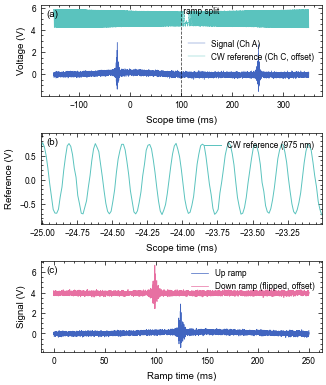

In [3]:
upRampSignal, downRampSignal, upRef, downRef, upTime, downTime, t, dt = \
    ia.split_interferogram_data(all_channel_a, all_channel_c, all_time)

# =============================================================================
# FIG S1: RAW OSCILLOSCOPE TRACE AND RAMP SPLITTING
# =============================================================================
iEx = 0  # example scan

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(cm*8.5, cm*10))

# (a) full, uncut oscilloscope record: signal + CW reference
tScope = all_time[iEx]
nFull = len(tScope)
ax1.plot(tScope, all_channel_a[iEx], color=cycle_colors[0], lw=0.3,
         label='Signal (Ch A)')
ax1.plot(tScope, all_channel_c[iEx] * 1 + 5, color=cycle_colors[2], lw=0.3,
         label=r'CW reference (Ch C, offset)')
ax1.axvline(tScope[nFull//2], color='k', ls='--', lw=0.6, alpha=0.7)
ax1.text(tScope[nFull//2], 0.98, ' ramp split', transform=ax1.get_xaxis_transform(),
         va='top', ha='left', fontsize=SMALL_SIZE)
ax1.set_xlabel('Scope time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.legend(frameon=False, loc='center right')
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, va='top', fontsize=MEDIUM_SIZE)

# (b) zoom on the CW reference fringes (middle of the up ramp)
zoomCtr = tScope[nFull//4]
ax2.plot(tScope, all_channel_c[iEx], color=cycle_colors[2], lw=0.7,
         label='CW reference (975 nm)')
ax2.set_xlim(zoomCtr, zoomCtr + 2.0)
ax2.set_xlabel('Scope time (ms)')
ax2.set_ylabel('Reference (V)')
ax2.legend(frameon=False, loc='upper right')
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, va='top', fontsize=MEDIUM_SIZE)

# (c) split at the midpoint; the down ramp is flipped to the same delay direction
ax3.plot(t, upRampSignal[iEx], color=cycle_colors[0], lw=0.5, label='Up ramp')
ax3.plot(t, downRampSignal[iEx] + 4, color=cycle_colors[1], lw=0.5,
         label='Down ramp (flipped, offset)')
ax3.set_xlabel('Ramp time (ms)')
ax3.set_ylabel('Signal (V)')
ax3.legend(frameon=False, loc='upper right')
ax3.text(0.02, 0.95, '(c)', transform=ax3.transAxes, va='top', fontsize=MEDIUM_SIZE)

plt.tight_layout()
export_fig(fig, "S1_raw_interferogram")
plt.show()

## Step 2 — Delay-axis calibration (Fig. S2)

The instantaneous phase of the CW reference (Hilbert transform, unwrapped) converts
the scan time of every individual scan into optical delay,
$\tau(t) = \lambda_{ref}\,\phi(t) / (2\pi c)$ with $\lambda_{ref}$ = 975 nm.
This removes the (nonlinear and irreproducible) motion of the voice coil. Fig. S2 shows
the mean delay trajectory with its scan-to-scan standard deviation, i.e. the timing
jitter that the coherent averaging has to correct.


exported S2_delay_calibration.pdf


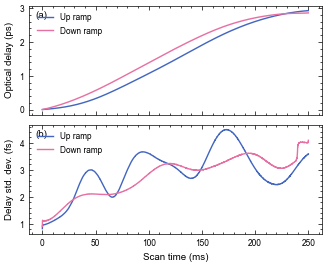

In [4]:
lambda_ref = 975e-9
tau_Up = (lambda_ref / c0) * ia.extract_phase(upRef, axis=1) / (2 * np.pi)
tau_Down = (lambda_ref / c0) * ia.extract_phase(downRef, axis=1) / (2 * np.pi)

# =============================================================================
# FIG S2: DELAY CALIBRATION AND SCAN-TO-SCAN JITTER
# =============================================================================
tauU_mean, tauU_std = np.mean(tau_Up, axis=0), np.std(tau_Up, axis=0)
tauD_mean, tauD_std = np.mean(tau_Down, axis=0), np.std(tau_Down, axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(cm*8.5, cm*7), sharex=True)

ax1.plot(t, tauU_mean*1e12, color=cycle_colors[0], label='Up ramp')
ax1.fill_between(t, (tauU_mean-tauU_std)*1e12, (tauU_mean+tauU_std)*1e12,
                 color=cycle_colors[0], alpha=0.3, lw=0)
ax1.plot(t, tauD_mean*1e12, color=cycle_colors[1], label='Down ramp')
ax1.fill_between(t, (tauD_mean-tauD_std)*1e12, (tauD_mean+tauD_std)*1e12,
                 color=cycle_colors[1], alpha=0.3, lw=0)
ax1.set_ylabel('Optical delay (ps)')
ax1.legend(frameon=False, loc='upper left')
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, va='top', fontsize=MEDIUM_SIZE)

ax2.plot(t, tauU_std*1e15, color=cycle_colors[0], label='Up ramp')
ax2.plot(t, tauD_std*1e15, color=cycle_colors[1], label='Down ramp')
ax2.set_xlabel('Scan time (ms)')
ax2.set_ylabel('Delay std. dev. (fs)')
ax2.legend(frameon=False, loc='upper left')
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, va='top', fontsize=MEDIUM_SIZE)

plt.tight_layout()
export_fig(fig, "S2_delay_calibration")
plt.show()


## Step 3 — Scan-band filtering for the alignment branch (Fig. S3)

For the *filtered branch* the raw signal is band-pass filtered in the scan-frequency
domain (Butterworth, order 5, zero-phase `filtfilt`, 400 Hz – 12 kHz). This isolates
the interferometric fringe band so the cross-correlation in the coherent averaging
locks robustly. **The filter is used only for alignment** — the unfiltered branch
below never passes through it.


dt_sec = 1.250e-05 s, Nyquist = 39987 Hz
exported S3_scan_filter.pdf


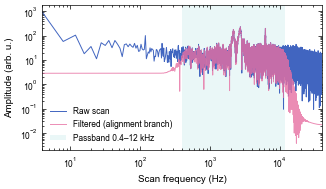

In [5]:
dt_sec = dt * 1e-3  # scope time base is in ms
f_low, f_high, f_order = 400.0, 12e3, 5
print(f"dt_sec = {dt_sec:.3e} s, Nyquist = {0.5/dt_sec:.0f} Hz")

filteredUpRampAll = np.zeros_like(upRampSignal)
filteredDownRampAll = np.zeros_like(downRampSignal)
for i in range(upRampSignal.shape[0]):
    filteredUpRampAll[i] = ia.apply_frequency_filter(upRampSignal[i], dt_sec,
                                                     lowcut=f_low, highcut=f_high, order=f_order)
    filteredDownRampAll[i] = ia.apply_frequency_filter(downRampSignal[i], dt_sec,
                                                       lowcut=f_low, highcut=f_high, order=f_order)

# =============================================================================
# FIG S3: SCAN-FREQUENCY SPECTRUM BEFORE / AFTER FILTERING
# =============================================================================
fscan = np.fft.rfftfreq(upRampSignal.shape[1], dt_sec)
spec_raw = np.abs(np.fft.rfft(upRampSignal[iEx]))
spec_fil = np.abs(np.fft.rfft(filteredUpRampAll[iEx]))

fig, ax = plt.subplots(figsize=(cm*8.5, cm*5))
ax.loglog(fscan[1:], spec_raw[1:], color=cycle_colors[0], lw=0.7, label='Raw scan')
ax.loglog(fscan[1:], spec_fil[1:], color=cycle_colors[1], lw=0.7, alpha=0.8,
          label='Filtered (alignment branch)')
ax.axvspan(f_low, f_high, color=cycle_colors[2], alpha=0.12, lw=0,
           label='Passband 0.4–12 kHz')
ax.set_xlabel('Scan frequency (Hz)')
ax.set_ylabel('Amplitude (arb. u.)')
ax.set_xlim(fscan[1], fscan[-1])
ax.legend(frameon=False, loc='lower left')

plt.tight_layout()
export_fig(fig, "S3_scan_filter")
plt.show()


## Step 4 — Resampling onto a uniform delay grid

Each scan is interpolated from its individual calibrated delay axis onto a common,
uniform delay grid (30 000 points). This is done for **both** branches with identical
parameters — the only difference between the branches at this point is the scan-band
filter.


In [6]:
tResampled = np.linspace(tau_Up[0].min() + 10e-15, tau_Up[0].max() * 0.95, 30000)
dtau = np.mean(np.diff(tResampled))
nS = len(tResampled)
print(f"Delay grid: {tResampled.min()*1e12:.3f} ps ... {tResampled.max()*1e12:.3f} ps, "
      f"dtau = {dtau*1e15:.3f} fs, f_Nyquist = {0.5/dtau*1e-12:.0f} THz")

nTr = tau_Up.shape[0]
interpFiltUp = np.zeros((nTr, nS))
interpFiltDown = np.zeros((nTr, nS))
interpRawUp = np.zeros((nTr, nS))
interpRawDown = np.zeros((nTr, nS))
for i in range(nTr):
    interpFiltUp[i] = ia.interpolate_interferogram(tau_Up[i], filteredUpRampAll[i], tResampled)
    interpFiltDown[i] = ia.interpolate_interferogram(tau_Down[i], filteredDownRampAll[i], tResampled)
    interpRawUp[i] = ia.interpolate_interferogram(tau_Up[i], upRampSignal[i], tResampled)
    interpRawDown[i] = ia.interpolate_interferogram(tau_Down[i], downRampSignal[i], tResampled)


Delay grid: 0.009 ps ... 2.783 ps, dtau = 0.092 fs, f_Nyquist = 5408 THz


## Step 5 — Coherent averaging with shift transfer (Fig. S4)

The adaptive coherent averaging cross-correlates every filtered trace against the
running average, shifts it by the detected offset (Fourier shift theorem, sub-sample
accuracy) and updates the average. `adaptive_coherent_average_with_shifts` additionally
returns the applied shift for every accepted trace and the valid-trace mask.

The **identical shifts and mask** are then applied to the unfiltered traces
(`average_with_precomputed_shifts`), yielding a coherently averaged interferogram that
never passed a spectral filter.


Up ramp:   832 of 833 traces averaged
Down ramp: 833 of 833 traces averaged
exported S4_coherent_averaging.pdf


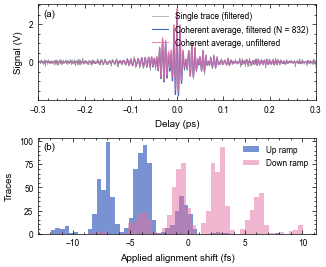

In [7]:
# --- filtered branch: adaptive averaging, keeping the alignment information ---
avgUp_filt, shiftsUp, validUp = ia.adaptive_coherent_average_with_shifts(
    interpFiltUp, dtau, n_bootstrap=1, update_rate=1)
avgDown_filt, shiftsDown, validDown = ia.adaptive_coherent_average_with_shifts(
    interpFiltDown, dtau, n_bootstrap=1, update_rate=1)

# --- unfiltered branch: identical alignment applied to the raw traces ---
avgUp_raw = ia.average_with_precomputed_shifts(
    interpRawUp, shiftsUp, validUp, dtau)
avgDown_raw = ia.average_with_precomputed_shifts(
    interpRawDown, shiftsDown, validDown, dtau)

print(f"Up ramp:   {validUp.sum()} of {nTr} traces averaged")
print(f"Down ramp: {validDown.sum()} of {nTr} traces averaged")

# =============================================================================
# FIG S4: SINGLE TRACE VS COHERENT AVERAGES + SHIFT STATISTICS
# =============================================================================
env = np.abs(sig.hilbert(avgUp_filt))
tPk = tResampled[env.argmax()]
tRel = (tResampled - tPk) * 1e12  # ps, centered on the pulse

singleFilt = interpFiltUp[validUp][0]
rawShow = avgUp_raw - np.mean(avgUp_raw)  # remove DC offset for display only

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(cm*8.5, cm*7))

ax1.plot(tRel, singleFilt, color='0.6', lw=0.5, label='Single trace (filtered)')
ax1.plot(tRel, avgUp_filt, color=cycle_colors[0], lw=0.8,
         label=f'Coherent average, filtered (N = {validUp.sum()})')
ax1.plot(tRel, rawShow, color=cycle_colors[1], lw=0.8, alpha=0.8,
         label='Coherent average, unfiltered')
ax1.set_xlim(-0.3, 0.3)
ax1.set_xlabel('Delay (ps)')
ax1.set_ylabel('Signal (V)')
ax1.legend(frameon=False, loc='upper right')
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, va='top', fontsize=MEDIUM_SIZE)

ax2.hist(shiftsUp[shiftsUp != 0] * 1e15, bins=50, color=cycle_colors[0], alpha=0.7,
         label='Up ramp')
ax2.hist(shiftsDown[shiftsDown != 0] * 1e15, bins=50, color=cycle_colors[1], alpha=0.5,
         label='Down ramp')
ax2.set_xlabel('Applied alignment shift (fs)')
ax2.set_ylabel('Traces')
ax2.legend(frameon=False, loc='upper right')
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, va='top', fontsize=MEDIUM_SIZE)

plt.tight_layout()
export_fig(fig, "S4_coherent_averaging")
plt.show()


## Step 6 — Noise floor and harmonic distortion (Fig. S5)

Power spectra (fundamental peak normalized) of

* a single **unfiltered** trace — the single-scan noise floor,
* the **unfiltered** coherent average — noise floor reduced by averaging, but all
  distortion products of the detection chain preserved,
* the **filtered** coherent average — what enters the main analysis.

Nonlinearity in the detection chain (photodiode / amplifier) generates harmonics of
the interferogram fringe frequency, which after delay calibration appear at integer
multiples $2f_0, 3f_0$ of the optical carrier frequency $f_0$. These bands are
quantified below relative to the fundamental.


Carrier frequency f0 = 159.4 THz  (lambda = 1.88 um)
exported S5_spectrum_noisefloor.pdf


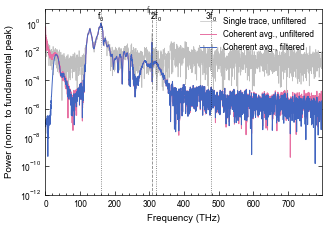

In [8]:
def power_spectrum(x):
    """Power spectrum with DC removed."""
    X = np.fft.rfft(x - np.mean(x))
    return np.abs(X) ** 2

fTHz = np.fft.rfftfreq(nS, dtau) * 1e-12

S_single = power_spectrum(interpRawUp[validUp][0])
S_rawavg = power_spectrum(avgUp_raw)
S_filtavg = power_spectrum(avgUp_filt)

# carrier frequency from the filtered average (search in the optical signal band)
sigBand = (fTHz > 50) & (fTHz < 300)
f0 = fTHz[sigBand][np.argmax(S_filtavg[sigBand])]
print(f"Carrier frequency f0 = {f0:.1f} THz  (lambda = {c0/(f0*1e12)*1e6:.2f} um)")

# Normalize each spectrum to its own fundamental (f0) peak, NOT the global maximum:
# the unfiltered traces contain low-frequency drift that exceeds the fundamental.
S_single_n = S_single / S_single[sigBand].max()
S_rawavg_n = S_rawavg / S_rawavg[sigBand].max()
S_filtavg_n = S_filtavg / S_filtavg[sigBand].max()

# =============================================================================
# FIG S5: OPTICAL POWER SPECTRA — NOISE FLOOR AND HARMONIC DISTORTION
# =============================================================================
fig, ax = plt.subplots(figsize=(cm*8.5, cm*6))

ax.semilogy(fTHz[1:], S_single_n[1:], color='0.75', lw=0.5, label='Single trace, unfiltered')
ax.semilogy(fTHz[1:], S_rawavg_n[1:], color=cycle_colors[1], lw=0.7,
            label='Coherent avg., unfiltered')
ax.semilogy(fTHz[1:], S_filtavg_n[1:], color=cycle_colors[0], lw=0.7,
            label='Coherent avg., filtered')

for k, name in [(1, '$f_0$'), (2, '$2f_0$'), (3, '$3f_0$')]:
    ax.axvline(k * f0, color='k', ls=':', lw=0.6, alpha=0.6)
    ax.text(k * f0, 2.0, name, ha='center', fontsize=SMALL_SIZE)

# CW reference leakage: any 975 nm light / channel crosstalk in the signal channel
# maps to exactly c/lambda_ref = 307.5 THz, because the delay axis is derived from
# the reference phase itself — the leak is phase-locked to the delay axis by
# construction and therefore survives coherent averaging as a sharp line.
f_ref = c0 / lambda_ref * 1e-12
ax.axvline(f_ref, color=cycle_colors[3], ls='--', lw=0.6, alpha=0.8)
ax.text(f_ref, 4.5, '$f_{ref}$', ha='center', fontsize=SMALL_SIZE, color=cycle_colors[3])

ax.set_xlim(0, 5 * f0)
ax.set_ylim(1e-12, 10)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Power (norm. to fundamental peak)')
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
export_fig(fig, "S5_spectrum_noisefloor")
plt.show()

In [9]:
# =============================================================================
# QUANTIFICATION: HARMONIC DISTORTION AND NOISE FLOOR
# =============================================================================
bandHW = 25.0  # half-width of the integration bands (THz)

def band_power(S, fc, hw=bandHW):
    m = (fTHz >= fc - hw) & (fTHz <= fc + hw)
    return S[m].sum()

fNy = fTHz[-1]
noiseBand = (min(4 * f0, 0.5 * fNy), min(8 * f0, 0.9 * fNy))  # signal-free region

print(f"Integration bands: +/- {bandHW} THz around f0, 2f0, 3f0")
print(f"Noise reference band: {noiseBand[0]:.0f} - {noiseBand[1]:.0f} THz\n")

for label, S in [("single unfiltered trace", S_single_n),
                 ("unfiltered coherent avg.", S_rawavg_n),
                 ("filtered coherent avg.  ", S_filtavg_n)]:
    P1 = band_power(S, f0)
    P2 = band_power(S, 2 * f0)
    P3 = band_power(S, 3 * f0)
    mNoise = (fTHz >= noiseBand[0]) & (fTHz <= noiseBand[1])
    floor_dB = 10 * np.log10(np.median(S[mNoise]))
    print(f"{label}:  2f0/f0 = {10*np.log10(P2/P1):6.1f} dB   "
          f"3f0/f0 = {10*np.log10(P3/P1):6.1f} dB   "
          f"spectral noise floor = {floor_dB:6.1f} dB")


Integration bands: +/- 25.0 THz around f0, 2f0, 3f0
Noise reference band: 637 - 1275 THz

single unfiltered trace:  2f0/f0 =  -14.9 dB   3f0/f0 =  -15.1 dB   spectral noise floor =  -27.5 dB
unfiltered coherent avg.:  2f0/f0 =  -21.5 dB   3f0/f0 =  -43.4 dB   spectral noise floor =  -56.8 dB
filtered coherent avg.  :  2f0/f0 =  -21.5 dB   3f0/f0 =  -43.5 dB   spectral noise floor =  -63.2 dB


## Step 7 — Final optical-band filter and complex field extraction (Fig. S8)

The averaged interferograms still contain out-of-band content: the low-frequency
baseline (< 40 THz drift) and the high-frequency noise floor / distortion products
discussed above. For the main analysis the averaged trace is band-pass filtered in the
**optical** frequency domain (Butterworth, order 4, 50 – 250 THz, zero-phase
`filtfilt`), the analytic signal is formed via the Hilbert transform, and the pulse is
centered on the delay grid by a linear spectral phase (Fourier-shift theorem). The
resulting complex fields (`up/down_field_centered_filtered`) are the quantities the
manuscript analysis consumes.

The **unfiltered branch is deliberately not passed through this step** — it stays
completely filter-free for the noise-floor and distortion analysis.

exported S8_optical_filter.pdf


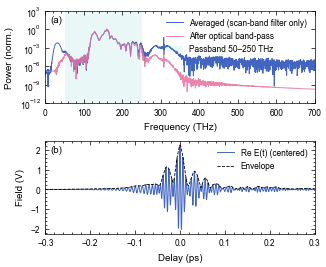

In [10]:
# =============================================================================
# FIG S8: FINAL OPTICAL-BAND FILTER AND COMPLEX FIELD EXTRACTION
# =============================================================================
opt_low, opt_high, opt_order = 50e12, 250e12, 4   # optical band-pass (main analysis values)

avgUp_optfilt = ia.apply_frequency_filter(avgUp_filt, dtau,
                                          lowcut=opt_low, highcut=opt_high, order=opt_order)
avgDown_optfilt = ia.apply_frequency_filter(avgDown_filt, dtau,
                                            lowcut=opt_low, highcut=opt_high, order=opt_order)

# analytic signal and centering (envelope peak -> center of the delay grid)
cmplxUp_centered = ia.center_signal(sig.hilbert(avgUp_optfilt), tResampled)
cmplxDown_centered = ia.center_signal(sig.hilbert(avgDown_optfilt), tResampled)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(cm*8.5, cm*7))

spec_before = np.abs(np.fft.rfft(avgUp_filt - avgUp_filt.mean()))**2
spec_after = np.abs(np.fft.rfft(avgUp_optfilt))**2
norm0 = spec_before[sigBand].max()
ax1.semilogy(fTHz[1:], spec_before[1:]/norm0, color=cycle_colors[0], lw=0.7,
             label='Averaged (scan-band filter only)')
ax1.semilogy(fTHz[1:], spec_after[1:]/norm0, color=cycle_colors[1], lw=0.7, alpha=0.85,
             label='After optical band-pass')
ax1.axvspan(opt_low*1e-12, opt_high*1e-12, color=cycle_colors[2], alpha=0.12, lw=0,
            label='Passband 50–250 THz')
ax1.set_xlim(0, 700)
ax1.set_ylim(1e-12, 1000)
ax1.set_xlabel('Frequency (THz)')
ax1.set_ylabel('Power (norm.)')
ax1.legend(frameon=False, loc='upper right')
ax1.text(0.02, 0.95, '(a)', transform=ax1.transAxes, va='top', fontsize=MEDIUM_SIZE)

tCentered = (tResampled - tResampled[nS//2]) * 1e12
ax2.plot(tCentered, np.real(cmplxUp_centered), color=cycle_colors[0], lw=0.7,
         label='Re E(t) (centered)')
ax2.plot(tCentered, np.abs(cmplxUp_centered), color='k', lw=0.6, ls='--',
         label='Envelope')
ax2.set_xlim(-0.3, 0.3)
ax2.set_xlabel('Delay (ps)')
ax2.set_ylabel('Field (V)')
ax2.legend(frameon=False, loc='upper right')
ax2.text(0.02, 0.95, '(b)', transform=ax2.transAxes, va='top', fontsize=MEDIUM_SIZE)

plt.tight_layout()
export_fig(fig, "S8_optical_filter")
plt.show()

## Step 8 — Export to HDF5

The unfiltered averaged dataset, the alignment shifts and the valid-trace masks are
stored next to the filtered-branch results in the same measurement group of
`experiment_dataV2.hdf5`.


In [11]:
if saveData:
    with h5py.File(hdf5_file_path, 'a') as f:
        g = f.require_group(f"{method}/{material}/{measurement_id}")

        datasets = {
            'time': tResampled,
            # filtered branch (identical pipeline to the main analysis notebook)
            'up_trace_averaged': avgUp_filt,
            'down_trace_averaged': avgDown_filt,
            # final optical-band-filtered, centered complex fields (main analysis input)
            'up_field_centered_filtered': cmplxUp_centered,
            'down_field_centered_filtered': cmplxDown_centered,
            # unfiltered branch (new): no spectral filtering at all, aligned with the
            # shifts obtained from the filtered branch
            'up_trace_averaged_unfiltered': avgUp_raw,
            'down_trace_averaged_unfiltered': avgDown_raw,
            'up_alignment_shifts': shiftsUp,
            'down_alignment_shifts': shiftsDown,
            'up_valid_mask': validUp,
            'down_valid_mask': validDown,
        }
        for name, data in datasets.items():
            if name in g:
                del g[name]
            g.create_dataset(name, data=data)

        for k in ['date', 'power', 'position', 'tag', 'method']:
            g.attrs[k] = metadata[k]
        g.attrs['unfiltered_note'] = (
            'Datasets *_unfiltered were coherently averaged WITHOUT any spectral '
            'filtering; alignment shifts were computed on the 400 Hz - 12 kHz '
            'scan-band-filtered traces and transferred (see up/down_alignment_shifts).')
        g.attrs['scan_filter'] = 'Butterworth order 5, 400 Hz - 12 kHz, filtfilt (alignment branch only)'
        g.attrs['optical_filter'] = ('Butterworth order 4, 50 - 250 THz, filtfilt; applied only to '
                                     '*_field_centered_filtered datasets')

    print(f"Data saved to: {hdf5_file_path}")
    print(f"Group: {method}/{material}/{measurement_id}")

Data saved to: c:/Coding/Nonlinear-Interactions-Campaign/Analysis/experiment_dataV2.hdf5
Group: 550/NoMaterial/pos_no_power_80mW_date_2025-03-11
